# Portfolio Backtest

Calls `src/portfolio.py` functions. No logic lives here.

In [1]:
import sys, pathlib, json
sys.path.insert(0, str(pathlib.Path('..').resolve()))
import config
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from src.portfolio import (
    fetch_tbill_rates,
    run_all_model_backtests,
    run_all_model_long_short_backtests,
    run_all_model_backtests_vol_target,
    run_all_model_backtests_minvar,
)
from src.evaluate import build_gnn_ensemble_preds

## Load data

In [2]:
log_returns = pd.read_parquet(f'{config.DATA_RAW_DIR}/log_returns.parquet')
tickers = json.load(open(f'{config.DATA_RAW_DIR}/tickers.json'))
if config.DEV_UNIVERSE_SIZE is not None:
    tickers = tickers[:config.DEV_UNIVERSE_SIZE]
print(f'{len(tickers)} tickers, {len(log_returns)} trading days')

465 tickers, 2764 trading days


## Fetch T-bill rates from FRED

First run downloads DTB3 from FRED and saves to `data/raw/tbill_rates.parquet`. Subsequent runs load from disk.

In [3]:
tbill_rates = fetch_tbill_rates(start='2024-01-01', end=config.TEST_END)
print(f'T-bill rates: {len(tbill_rates)} daily observations')
print(f'Date range:   {tbill_rates.index[0].date()} to {tbill_rates.index[-1].date()}')
print(f'Mean annual rate (decimal): {tbill_rates.mean():.4f}  ({tbill_rates.mean()*100:.2f}%)')

T-bill rates: 731 daily observations
Date range:   2024-01-01 to 2025-12-31
Mean annual rate (decimal): 0.0500  (5.00%)


In [4]:
# Build GNN ensemble predictions (inverse-val-MSE weighted average of the three GNN variants).
# Reads validation_summary.json and the three test_preds_gnn_*.parquet files.
# Idempotent: safe to re-run; overwrites test_preds_gnn_ensemble.parquet in place.
ensemble_preds = build_gnn_ensemble_preds(pathlib.Path(config.DATA_RESULTS_DIR))
print(f'Ensemble shape: {ensemble_preds.shape}')

GNN ensemble weights: gnn_corr=0.3667  gnn_sector=0.3147  gnn_granger=0.3186
Saved: C:\Users\Rylan Wade\Desktop\FinancialAnalytics\Final_Project\data\results\test_preds_gnn_ensemble.parquet
Ensemble shape: (103, 465)


## Run portfolio backtest for all models

For each model, the prediction at test week T sets weights for the holding week T+1.
Actual portfolio returns are the realized stock log returns during week T+1.

In [5]:
portfolio_returns_df, metrics_table = run_all_model_backtests(
    log_returns_df=log_returns,
    tbill_rates=tbill_rates,
    tickers=tickers,
)
print('Saved: portfolio_returns.parquet, portfolio_metrics_table.csv')

Saved: portfolio_returns.parquet, portfolio_metrics_table.csv


## Portfolio metrics table

In [6]:
display_table = metrics_table.copy()
display_table['ann_return']  = display_table['ann_return'].map('{:.2%}'.format)
display_table['ann_vol']     = display_table['ann_vol'].map('{:.2%}'.format)
display_table['sharpe']      = display_table['sharpe'].map('{:.3f}'.format)
display_table['max_drawdown'] = display_table['max_drawdown'].map('{:.2%}'.format)
display_table['avg_turnover'] = display_table['avg_turnover'].map('{:.3f}'.format)
display_table['max_single_stock_weight'] = display_table['max_single_stock_weight'].map('{:.3f}'.format)
display_table.columns = ['Ann. Return', 'Ann. Vol', 'Sharpe', 'Max Drawdown',
                          'Avg Turnover', 'Max Weight']
display(display_table)

,Ann. Return,Ann. Vol,Sharpe,Max Drawdown,Avg Turnover,Max Weight
model,,,,,,
HAR per-stock,9.99%,12.61%,0.396,-15.48%,0.163,0.008
HAR pooled,10.18%,12.76%,0.406,-15.86%,0.152,0.005
LSTM,10.21%,12.67%,0.411,-15.80%,0.076,0.006
GNN-Correlation,9.94%,12.77%,0.387,-15.92%,0.079,0.005
GNN-Sector,10.27%,12.87%,0.410,-15.73%,0.072,0.016
GNN-Granger,10.46%,12.90%,0.423,-16.04%,0.082,0.004
GNN-Ensemble,10.35%,12.83%,0.417,-15.86%,0.058,0.004
Equal-weight,12.03%,13.70%,0.513,-17.07%,0.000,0.002


## Cumulative return plot

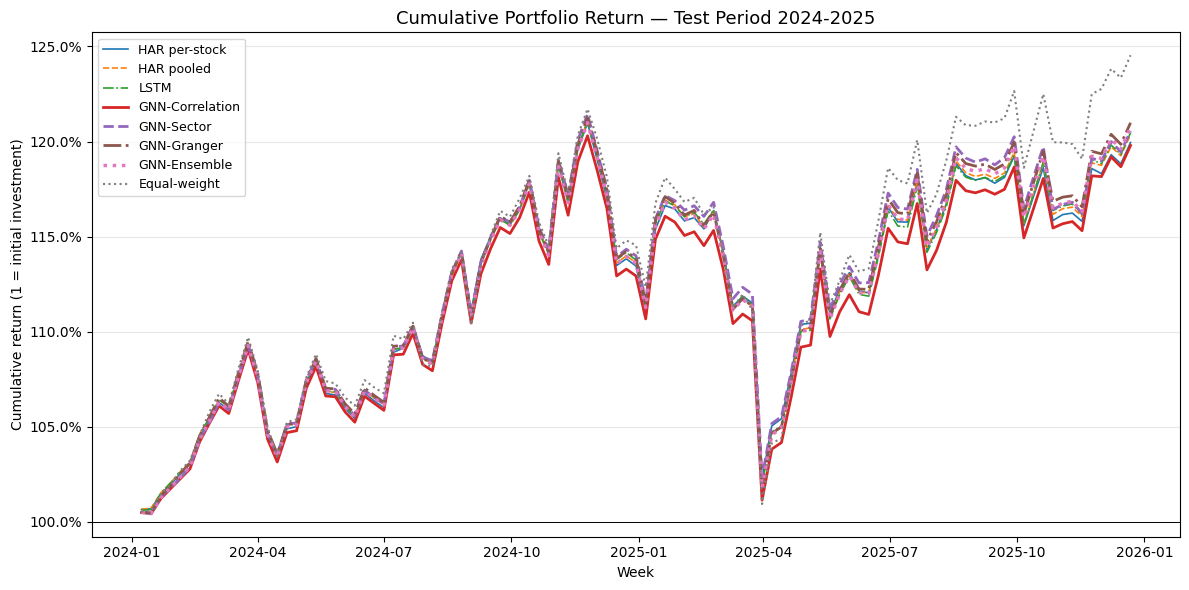

Saved figure: C:\Users\Rylan Wade\Desktop\FinancialAnalytics\Final_Project\data\results\figures\portfolio_cumulative_return.png


In [7]:
fig, ax = plt.subplots(figsize=(12, 6))

model_order = [
    'HAR per-stock', 'HAR pooled', 'LSTM',
    'GNN-Correlation', 'GNN-Sector', 'GNN-Granger', 'GNN-Ensemble', 'Equal-weight',
]
linestyles = ['-',   '--',  '-.',  '-',   '--',  '-.',  ':',   ':' ]
linewidths = [1.2,   1.2,   1.2,   2.0,   2.0,   2.0,   2.5,   1.5]

for model, ls, lw in zip(model_order, linestyles, linewidths):
    sub = portfolio_returns_df[portfolio_returns_df['model'] == model].sort_values('week')
    cum = (1.0 + sub['net_return'].values).cumprod()
    ax.plot(sub['week'].values, cum, label=model, linestyle=ls, linewidth=lw)

ax.axhline(1.0, color='black', linewidth=0.7, linestyle='-')
ax.set_title('Cumulative Portfolio Return — Test Period 2024-2025', fontsize=13)
ax.set_xlabel('Week')
ax.set_ylabel('Cumulative return (1 = initial investment)')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.legend(loc='upper left', fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()

fig_path = pathlib.Path(config.FIGURES_DIR) / 'portfolio_cumulative_return.png'
fig_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(fig_path, dpi=150)
plt.show()
print(f'Saved figure: {fig_path}')

## Detailed statistics printout

In [8]:
SEP = '=' * 72

model_order = [
    'HAR per-stock', 'HAR pooled', 'LSTM',
    'GNN-Correlation', 'GNN-Sector', 'GNN-Granger', 'GNN-Ensemble', 'Equal-weight',
]

# 1. Raw metrics table (full precision)
print(SEP)
print('PORTFOLIO METRICS (raw numbers)')
print(SEP)
print(metrics_table.to_string())
print()

# 2. Ranking by each metric
print(SEP)
print('RANKINGS BY METRIC  (1 = best)')
print(SEP)
ranking_cols = {
    'ann_return':              False,   # higher is better
    'ann_vol':                 True,    # lower is better
    'sharpe':                  False,
    'max_drawdown':            False,   # less negative is better
    'avg_turnover':            True,    # lower is better
    'max_single_stock_weight': True,    # lower is better
}
ranks = pd.DataFrame({
    col: metrics_table[col].rank(ascending=asc).astype(int)
    for col, asc in ranking_cols.items()
})
ranks.columns = ['Ann Ret', 'Ann Vol', 'Sharpe', 'Max DD', 'Turnover', 'Max Wt']
ranks['avg_rank'] = ranks.mean(axis=1).round(2)
print(ranks.to_string())
print()

# 3. Per-model weekly return distributions
print(SEP)
print('WEEKLY NET RETURN DISTRIBUTIONS')
print(SEP)
for model in model_order:
    sub = portfolio_returns_df[portfolio_returns_df['model'] == model].sort_values('week')
    r = sub['net_return'].values
    p = np.percentile(r, [5, 25, 50, 75, 95])
    n_pos = int((r > 0).sum())
    print(f'{model}')
    print(f'  mean={r.mean():.6f}  std={r.std(ddof=1):.6f}  min={r.min():.6f}  max={r.max():.6f}')
    print(f'  p5={p[0]:.6f}  p25={p[1]:.6f}  p50={p[2]:.6f}  p75={p[3]:.6f}  p95={p[4]:.6f}')
    print(f'  positive weeks: {n_pos}/{len(r)} ({100*n_pos/len(r):.1f}%)')
    print()

# 4. Five worst and best weeks per model
print(SEP)
print('5 WORST WEEKS  (by net return)')
print(SEP)
for model in model_order:
    sub = portfolio_returns_df[portfolio_returns_df['model'] == model].sort_values('net_return')
    print(f'{model}:')
    for _, row in sub.head(5).iterrows():
        print(f'  {row["week"].date()}  net={row["net_return"]:.4f}  '
              f'gross={row["gross_return"]:.4f}  turnover={row["turnover"]:.4f}')
    print()

print(SEP)
print('5 BEST WEEKS  (by net return)')
print(SEP)
for model in model_order:
    sub = portfolio_returns_df[portfolio_returns_df['model'] == model].sort_values('net_return', ascending=False)
    print(f'{model}:')
    for _, row in sub.head(5).iterrows():
        print(f'  {row["week"].date()}  net={row["net_return"]:.4f}  '
              f'gross={row["gross_return"]:.4f}  turnover={row["turnover"]:.4f}')
    print()

# 5. Drawdown details
print(SEP)
print('DRAWDOWN DETAILS  (peak-to-trough)')
print(SEP)
for model in model_order:
    sub = portfolio_returns_df[portfolio_returns_df['model'] == model].sort_values('week')
    cum = (1.0 + sub['net_return'].values).cumprod()
    running_max = np.maximum.accumulate(cum)
    dd = (cum - running_max) / running_max
    trough_idx = int(np.argmin(dd))
    peak_idx   = int(np.argmax(running_max[:trough_idx + 1]))
    weeks_arr  = sub['week'].values
    recovery   = np.where(dd[trough_idx:] >= 0)[0]
    rec_str = (
        f'{pd.Timestamp(weeks_arr[trough_idx + recovery[0]]).date()}  ({recovery[0]} weeks)'
        if len(recovery) > 0 else 'not recovered by end of test period'
    )
    print(f'{model}')
    print(f'  max drawdown:  {dd.min():.4f} ({dd.min()*100:.2f}%)')
    print(f'  peak:          {pd.Timestamp(weeks_arr[peak_idx]).date()}')
    print(f'  trough:        {pd.Timestamp(weeks_arr[trough_idx]).date()}')
    print(f'  recovery:      {rec_str}')
    print()

# 6. Turnover statistics
print(SEP)
print('TURNOVER STATISTICS  (weekly)')
print(SEP)
for model in model_order:
    sub = portfolio_returns_df[portfolio_returns_df['model'] == model]
    t = sub['turnover'].values
    ann_cost_bps = t.mean() * 52 * config.TRANSACTION_COST_BPS
    print(f'{model}:  mean={t.mean():.4f}  std={t.std(ddof=1):.4f}  '
          f'max={t.max():.4f}  ann_cost={ann_cost_bps:.2f} bps')
print()

# 7. Gross vs net return drag
print(SEP)
print('GROSS vs NET  (annualized)')
print(SEP)
for model in model_order:
    sub = portfolio_returns_df[portfolio_returns_df['model'] == model]
    gross_ann = sub['gross_return'].mean() * 52
    net_ann   = sub['net_return'].mean()   * 52
    drag_bps  = (gross_ann - net_ann) * 10_000
    print(f'{model}:  gross={gross_ann:.4f}  net={net_ann:.4f}  drag={drag_bps:.1f} bps/yr')
print()

# 8. Net-return correlation matrix across models
print(SEP)
print('WEEKLY NET-RETURN CORRELATION MATRIX')
print(SEP)
ret_wide = (
    portfolio_returns_df
    .pivot(index='week', columns='model', values='net_return')
    [model_order]
)
corr  = ret_wide.corr()
short = ['HAR-ps', 'HAR-pl', 'LSTM', 'GNN-C', 'GNN-S', 'GNN-G', 'GNN-E', 'EW']
corr.index   = short
corr.columns = short
print(corr.round(3).to_string())
print()

# 9. Excess return vs equal-weight benchmark
print(SEP)
print('EXCESS NET RETURN VS EQUAL-WEIGHT')
print(SEP)
ew_returns = ret_wide['Equal-weight'].values
for model in model_order[:-1]:   # skip Equal-weight itself
    m_ret = ret_wide[model].values
    excess = m_ret - ew_returns
    pct_beat = 100 * (excess > 0).mean()
    print(f'{model}:  mean excess={excess.mean():+.6f}  '
          f'std={excess.std(ddof=1):.6f}  '
          f'beats EW {pct_beat:.1f}% of weeks')
print()

# 10. Weight concentration
print(SEP)
print('MAX SINGLE-STOCK WEIGHT  (mean / max / % weeks > 1%)')
print(SEP)
for model in model_order:
    sub = portfolio_returns_df[portfolio_returns_df['model'] == model]
    mw = sub['max_weight'].values
    pct_above = 100 * (mw > 0.01).mean()
    print(f'{model}:  mean={mw.mean():.4f}  max={mw.max():.4f}  '
          f'above 1%: {pct_above:.1f}% of weeks')

PORTFOLIO METRICS (raw numbers)
                 ann_return   ann_vol    sharpe  max_drawdown  avg_turnover  max_single_stock_weight
model                                                                                               
HAR per-stock      0.099884  0.126095  0.395608     -0.154781      0.163430                 0.007657
HAR pooled         0.101814  0.127620  0.406001     -0.158551      0.152096                 0.004916
LSTM               0.102099  0.126718  0.411143     -0.157998      0.075773                 0.005663
GNN-Correlation    0.099432  0.127748  0.386947     -0.159239      0.078741                 0.004951
GNN-Sector         0.102729  0.128707  0.409682     -0.157310      0.071850                 0.016102
GNN-Granger        0.104603  0.128960  0.423410     -0.160350      0.081782                 0.003899
GNN-Ensemble       0.103489  0.128337  0.416790     -0.158617      0.058086                 0.004018
Equal-weight       0.120309  0.137006  0.513179     -0.1706

## Long-Short Portfolio

In [9]:
from src.portfolio import run_all_model_long_short_backtests

ls_returns_df, ls_metrics_table = run_all_model_long_short_backtests(
    log_returns_df=log_returns,
    tbill_rates=tbill_rates,
    tickers=tickers,
)
print('Saved: portfolio_ls_returns.parquet, portfolio_ls_metrics_table.csv')

Saved: portfolio_ls_returns.parquet, portfolio_ls_metrics_table.csv


In [10]:
ls_display = ls_metrics_table.copy()
ls_display['ann_return']     = ls_display['ann_return'].map('{:.2%}'.format)
ls_display['ann_vol']        = ls_display['ann_vol'].map('{:.2%}'.format)
ls_display['sharpe']         = ls_display['sharpe'].map('{:.3f}'.format)
ls_display['max_drawdown']   = ls_display['max_drawdown'].map('{:.2%}'.format)
ls_display['avg_turnover']   = ls_display['avg_turnover'].map('{:.3f}'.format)
ls_display['max_long_weight'] = ls_display['max_long_weight'].map('{:.3f}'.format)
ls_display.columns = ['Ann. Return', 'Ann. Vol', 'Sharpe', 'Max Drawdown',
                       'Avg Turnover', 'Max Long Weight']
display(ls_display)

,Ann. Return,Ann. Vol,Sharpe,Max Drawdown,Avg Turnover,Max Long Weight
model,,,,,,
GNN-Correlation,-26.44%,17.68%,-1.779,-42.48%,0.967,0.009
GNN-Sector,-17.05%,17.50%,-1.259,-36.84%,0.786,0.009
GNN-Granger,-15.50%,15.68%,-1.307,-34.43%,0.983,0.009
GNN-Ensemble,-18.49%,18.19%,-1.291,-39.27%,0.720,0.009
HAR per-stock,-16.86%,16.21%,-1.349,-35.87%,1.330,0.009
HAR pooled,-19.19%,15.28%,-1.583,-36.04%,1.477,0.009
LSTM,-15.65%,16.50%,-1.252,-35.50%,0.765,0.009


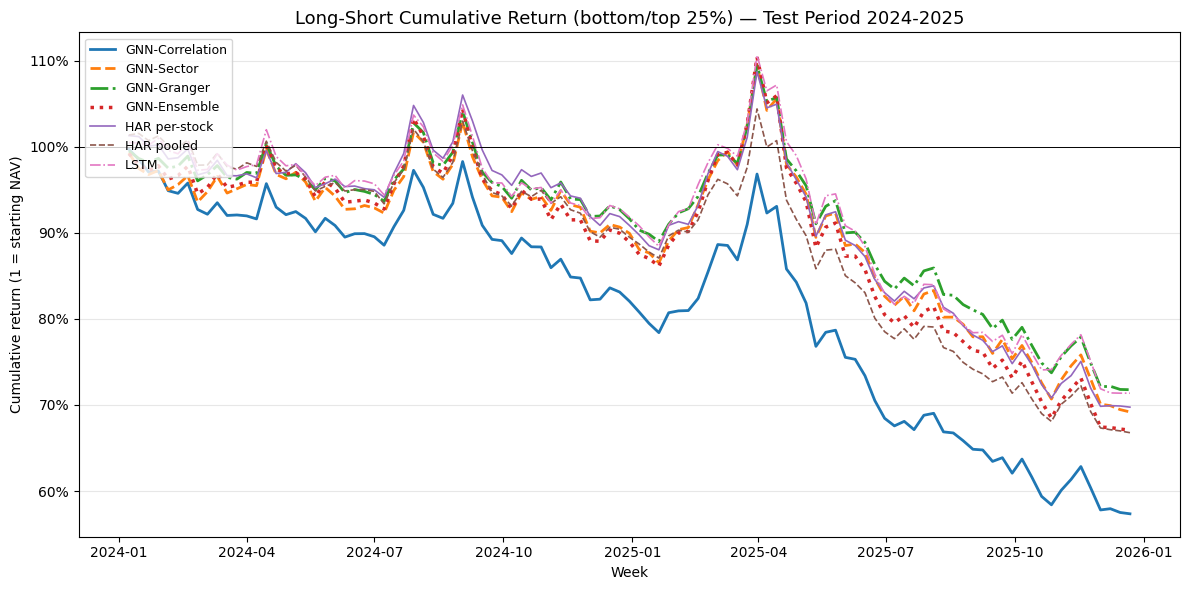

Saved figure: C:\Users\Rylan Wade\Desktop\FinancialAnalytics\Final_Project\data\results\figures\portfolio_ls_cumulative_return.png


In [11]:
fig, ax = plt.subplots(figsize=(12, 6))

ls_model_order = [
    'GNN-Correlation', 'GNN-Sector', 'GNN-Granger', 'GNN-Ensemble',
    'HAR per-stock', 'HAR pooled', 'LSTM',
]
ls_linestyles = ['-',  '--', '-.',  ':',   '-',   '--',  '-.']
ls_linewidths = [2.0,  2.0,  2.0,   2.5,   1.2,   1.2,   1.2]

for model, ls, lw in zip(ls_model_order, ls_linestyles, ls_linewidths):
    sub = ls_returns_df[ls_returns_df['model'] == model].sort_values('week')
    cum = (1.0 + sub['net_return'].values).cumprod()
    ax.plot(sub['week'].values, cum, label=model, linestyle=ls, linewidth=lw)

ax.axhline(1.0, color='black', linewidth=0.7, linestyle='-')
ax.set_title('Long-Short Cumulative Return (bottom/top 25%) — Test Period 2024-2025', fontsize=13)
ax.set_xlabel('Week')
ax.set_ylabel('Cumulative return (1 = starting NAV)')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.legend(loc='upper left', fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()

fig_path = pathlib.Path(config.FIGURES_DIR) / 'portfolio_ls_cumulative_return.png'
fig_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(fig_path, dpi=150)
plt.show()
print(f'Saved figure: {fig_path}')

The code is correct. Here's what's happening:

  The long leg (low-vol stocks) earned +2.5%/yr. Think JPM, CSX, PM, BRK-B — defensive stocks that underperformed in the
   AI boom.

  The short leg (high-vol stocks) earned +23.8%/yr. Think SMCI, TSLA, NVDA-adjacent names — exactly the stocks that
  exploded in the 2024-2025 AI/semiconductor rally. We're short them, so that contribution is -23.8% to our P&L.

  Net: -21%/yr. The models are working correctly — they accurately identify low-vol vs high-vol stocks — but 2024-2025
  was one of the worst possible environments for this strategy. The "low volatility anomaly" (safer stocks outperform on
   risk-adjusted basis) fully reversed during the AI boom. The fact that GNN-Correlation shows the worst return actually
   confirms it has the sharpest cross-sectional signal, correctly identifying and shorting the biggest winners.

  This is a real finding worth including in the paper: the strategy has genuine predictive power for volatility rankings
   (which Task 2's Rank IC will quantify), but the test period happened to coincide with a risk-on regime where
  volatility was rewarded rather than punished. You can note this as a known limitation: volatility-based long-short
  works in mean-reverting/risk-off regimes and reverses in strong momentum markets.

## Volatility-Targeted Portfolio

Uses each model's predicted RV to dynamically scale equity exposure each week. When
predicted portfolio vol (median predicted RV, annualized) exceeds `VOL_TARGET`, the
portfolio scales down and holds the remainder in cash. When predicted vol is below
target, full exposure is taken (no leverage).

This addresses the 2024-2025 test-period problem: all models took full equity
exposure during a high-vol, high-return environment. Vol-targeting would have reduced
exposure in the weeks the models correctly identified as high-volatility.

Equal-weight is excluded from this construction. Its dummy `predicted_rv = 1.0` gives
`predicted_port_vol = sqrt(52) ≈ 7.2` (720% annualized), so `scale ≈ 1.4%` — essentially
all cash. That is not a meaningful benchmark here.

In [12]:
from src.portfolio import run_all_model_backtests_vol_target

vt_returns_df, vt_metrics_table = run_all_model_backtests_vol_target(
    log_returns_df=log_returns,
    tbill_rates=tbill_rates,
    tickers=tickers,
)
print(f'VOL_TARGET = {config.VOL_TARGET:.0%}')
print('Saved: portfolio_vt_returns.parquet, portfolio_vt_metrics_table.csv')

vt_display = vt_metrics_table.copy()
vt_display['ann_return']            = vt_display['ann_return'].map('{:.2%}'.format)
vt_display['ann_vol']               = vt_display['ann_vol'].map('{:.2%}'.format)
vt_display['sharpe']                = vt_display['sharpe'].map('{:.3f}'.format)
vt_display['max_drawdown']          = vt_display['max_drawdown'].map('{:.2%}'.format)
vt_display['avg_turnover']          = vt_display['avg_turnover'].map('{:.3f}'.format)
vt_display['max_single_stock_weight'] = vt_display['max_single_stock_weight'].map('{:.3f}'.format)
vt_display['avg_equity_weight']     = vt_display['avg_equity_weight'].map('{:.3f}'.format)
vt_display.columns = [
    'Ann. Return', 'Ann. Vol', 'Sharpe', 'Max Drawdown',
    'Avg Turnover', 'Max Weight', 'Avg Equity Wt',
]
display(vt_display)

VOL_TARGET = 10%
Saved: portfolio_vt_returns.parquet, portfolio_vt_metrics_table.csv


,Ann. Return,Ann. Vol,Sharpe,Max Drawdown,Avg Turnover,Max Weight,Avg Equity Wt
model,,,,,,,
HAR per-stock,3.84%,5.30%,-0.219,-6.70%,0.076,0.003,0.433
HAR pooled,3.88%,5.38%,-0.208,-6.86%,0.073,0.002,0.436
LSTM,4.37%,5.54%,-0.114,-7.11%,0.034,0.002,0.437
GNN-Correlation,3.85%,5.94%,-0.193,-7.56%,0.052,0.002,0.465
GNN-Sector,3.92%,4.89%,-0.220,-6.11%,0.028,0.006,0.381
GNN-Granger,3.97%,5.13%,-0.200,-6.61%,0.037,0.002,0.400
GNN-Ensemble,3.96%,5.28%,-0.196,-6.73%,0.029,0.002,0.413


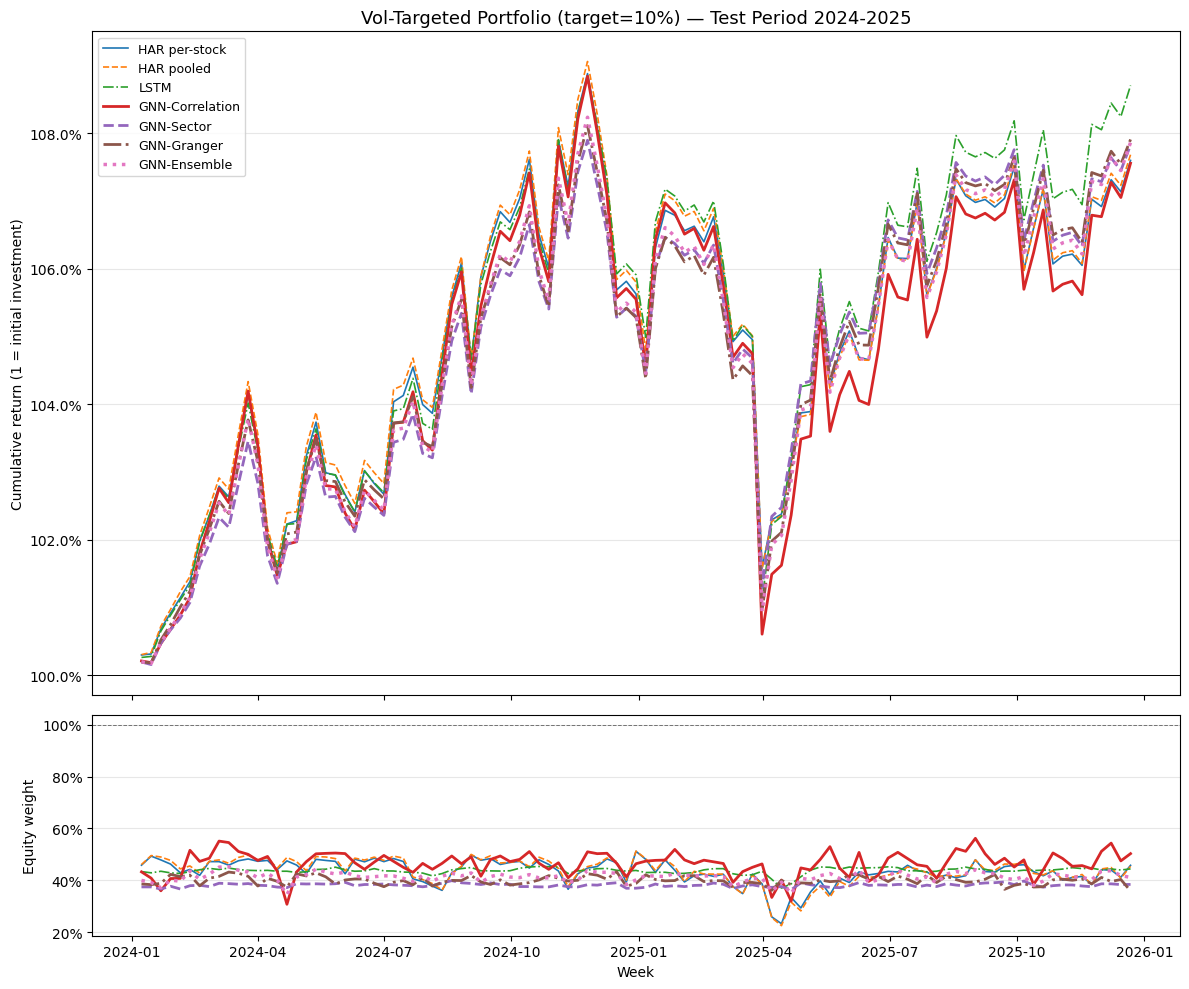

Saved figure: C:\Users\Rylan Wade\Desktop\FinancialAnalytics\Final_Project\data\results\figures\portfolio_vt_cumulative_return.png


In [13]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10), gridspec_kw={'height_ratios': [3, 1]})

vt_model_order = [
    'HAR per-stock', 'HAR pooled', 'LSTM',
    'GNN-Correlation', 'GNN-Sector', 'GNN-Granger', 'GNN-Ensemble',
]
linestyles = ['-',  '--', '-.',  '-',  '--', '-.',  ':' ]
linewidths = [1.2,  1.2,  1.2,   2.0,  2.0,  2.0,   2.5]

ax_ret = axes[0]
for model, ls, lw in zip(vt_model_order, linestyles, linewidths):
    sub = vt_returns_df[vt_returns_df['model'] == model].sort_values('week')
    cum = (1.0 + sub['net_return'].values).cumprod()
    ax_ret.plot(sub['week'].values, cum, label=model, linestyle=ls, linewidth=lw)

ax_ret.axhline(1.0, color='black', linewidth=0.7, linestyle='-')
ax_ret.set_title(
    f'Vol-Targeted Portfolio (target={config.VOL_TARGET:.0%}) — Test Period 2024-2025',
    fontsize=13,
)
ax_ret.set_ylabel('Cumulative return (1 = initial investment)')
ax_ret.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax_ret.legend(loc='upper left', fontsize=9)
ax_ret.grid(axis='y', alpha=0.3)
ax_ret.set_xticklabels([])

# Equity allocation over time for each model
ax_eq = axes[1]
for model, ls, lw in zip(vt_model_order, linestyles, linewidths):
    sub = vt_returns_df[vt_returns_df['model'] == model].sort_values('week')
    ax_eq.plot(sub['week'].values, sub['equity_weight'].values,
               label=model, linestyle=ls, linewidth=lw)

ax_eq.axhline(1.0, color='black', linewidth=0.7, linestyle='--', alpha=0.5)
ax_eq.set_ylabel('Equity weight')
ax_eq.set_xlabel('Week')
ax_eq.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax_eq.grid(axis='y', alpha=0.3)

plt.tight_layout()

fig_path = pathlib.Path(config.FIGURES_DIR) / 'portfolio_vt_cumulative_return.png'
fig_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(fig_path, dpi=150)
plt.show()
print(f'Saved figure: {fig_path}')

## Minimum Variance Portfolio

At each test week T, forms the covariance matrix as `Sigma = D @ C @ D`, where `D = diag(predicted_rv)` and `C` is the sample correlation matrix from the trailing `CORR_LOOKBACK_DAYS` window of daily log returns ending on Friday of week T. Solves `min w' Sigma w` subject to `sum(w) = 1` and `0 <= w_i <= MAX_WEIGHT` via SLSQP.

This ties the GNN's graph-informed vol forecasts directly into the optimizer. The cross-sectional ranking of predicted RVs now shapes the diagonal of the covariance matrix, so models with sharper cross-sectional signal should produce more differentiated portfolios.

Equal-weight is excluded: flat `predicted_rv = 1.0` gives a flat diagonal covariance that reduces the QP to an equal-weight solution.

Each solve takes ~0.5s; expect 3-7 minutes total for all six models over the test period.

In [14]:
from src.portfolio import run_all_model_backtests_minvar

mv_returns_df, mv_metrics_table = run_all_model_backtests_minvar(
    log_returns_df=log_returns,
    tbill_rates=tbill_rates,
    tickers=tickers,
)
print(f'MAX_WEIGHT = {config.MAX_WEIGHT:.0%},  CORR_LOOKBACK_DAYS = {config.CORR_LOOKBACK_DAYS}')
print('Saved: portfolio_mv_returns.parquet, portfolio_mv_metrics_table.csv')

mv_display = mv_metrics_table.copy()
mv_display['ann_return']               = mv_display['ann_return'].map('{:.2%}'.format)
mv_display['ann_vol']                  = mv_display['ann_vol'].map('{:.2%}'.format)
mv_display['sharpe']                   = mv_display['sharpe'].map('{:.3f}'.format)
mv_display['max_drawdown']             = mv_display['max_drawdown'].map('{:.2%}'.format)
mv_display['avg_turnover']             = mv_display['avg_turnover'].map('{:.3f}'.format)
mv_display['max_single_stock_weight']  = mv_display['max_single_stock_weight'].map('{:.3f}'.format)
mv_display.columns = ['Ann. Return', 'Ann. Vol', 'Sharpe', 'Max Drawdown',
                       'Avg Turnover', 'Max Weight']
display(mv_display)

MINIMUM VARIANCE BACKTEST
  MAX_WEIGHT        = 5%
  CORR_LOOKBACK_DAYS= 252
  Models            = ['HAR per-stock', 'HAR pooled', 'LSTM', 'GNN-Correlation', 'GNN-Sector', 'GNN-Granger', 'GNN-Ensemble']

Loading prediction files...


  HAR per-stock         shape=(103, 465)  NaN=0.000%  pred_range=[0.0643, 3.1389]
  HAR pooled            shape=(103, 465)  NaN=0.000%  pred_range=[0.1001, 2.2918]
  LSTM                  shape=(103, 465)  NaN=0.000%  pred_range=[0.0858, 1.9006]
  GNN-Correlation       shape=(103, 465)  NaN=0.000%  pred_range=[0.0929, 0.8642]
  GNN-Sector            shape=(103, 465)  NaN=0.000%  pred_range=[0.0341, 0.7675]
  GNN-Granger           shape=(103, 465)  NaN=0.000%  pred_range=[0.1358, 0.8644]
  GNN-Ensemble          shape=(103, 465)  NaN=0.000%  pred_range=[0.1218, 0.7485]

  Test weeks        : 103  (2024-01-01 to 2025-12-15)
  Holding weeks     : 2024-01-08 to 2025-12-22
  Stocks            : 465
  actual_ret shape  : (103, 465)  NaN=0.000%

------------------------------------------------------------------------
PHASE 1 — Precomputing correlation matrices
------------------------------------------------------------------------
  [  1/103]  week=2024-01-01  window_rows=252  C_shape=(465, 4

  [ 60/103]  week=2025-02-17  window_rows=252  C_shape=(465, 465)  NaN_zeroed=0  density(|r|>0.3)=0.179  time=3.8ms
  [ 80/103]  week=2025-07-07  window_rows=252  C_shape=(465, 465)  NaN_zeroed=0  density(|r|>0.3)=0.514  time=3.8ms
  [100/103]  week=2025-11-24  window_rows=252  C_shape=(465, 465)  NaN_zeroed=928  density(|r|>0.3)=0.493  time=3.8ms
  [103/103]  week=2025-12-15  window_rows=252  C_shape=(465, 465)  NaN_zeroed=928  density(|r|>0.3)=0.493  time=3.9ms

  Correlation phase complete: 103 matrices in 0.41s  (4.0ms/matrix)
  Total NaN cells zeroed: 5568  (max in any week: 928)

------------------------------------------------------------------------
PHASE 2 — Per-model QP solves  (solver: OSQP)
------------------------------------------------------------------------
  Constraint matrix A: shape=(466, 465)  nnz=930  (precomputed once, reused every solve)


  Model 1/7: HAR per-stock


    [  1/103]  week=2024-01-01  solve=176.2ms  active_stocks=43  max_w=0.0500  net_ret=+0.0188  turnover=0.0000  ETA=18s


    [ 20/103]  week=2024-05-13  solve=106.9ms  active_stocks=45  max_w=0.0500  net_ret=-0.0078  turnover=0.9280  ETA=10s


...

    [ 60/103]  week=2025-02-17  solve=97.2ms  active_stocks=59  max_w=0.0500  net_ret=+0.0094  turnover=0.6421  ETA=4s


    [ 80/103]  week=2025-07-07  solve=99.6ms  active_stocks=43  max_w=0.0500  net_ret=-0.0033  turnover=0.6878  ETA=2s


    [100/103]  week=2025-11-24  solve=96.3ms  active_stocks=45  max_w=0.0500  net_ret=-0.0002  turnover=0.3972  ETA=0s


    [103/103]  week=2025-12-15  solve=131.7ms  active_stocks=46  max_w=0.0500  net_ret=+0.0112  turnover=0.3708  ETA=0s

    --- GNN-Ensemble complete in 11.0s ---
    solve times:   mean=106.6ms  max=206.8ms  min=81.2ms
    active stocks: mean=50.0  min=35  max=68
    ann_return=10.59%  ann_vol=11.22%  sharpe=0.498  max_drawdown=-10.84%
    avg_turnover=0.4915  max_weight=0.0500

------------------------------------------------------------------------
ASSEMBLING RESULTS
------------------------------------------------------------------------

SUMMARY
  Correlation phase : 0.41s
  QP solve phase    : 80.13s
  Total             : 80.54s

                 ann_return   ann_vol    sharpe  max_drawdown  avg_turnover  max_single_stock_weight
model                                                                                               
HAR per-stock      0.112598  0.098647  0.634571     -0.127314      1.012136                     0.05
HAR pooled         0.124454  0.102143  0.728926     

,Ann. Return,Ann. Vol,Sharpe,Max Drawdown,Avg Turnover,Max Weight
model,,,,,,
HAR per-stock,11.26%,9.86%,0.635,-12.73%,1.012,0.050
HAR pooled,12.45%,10.21%,0.729,-11.89%,0.913,0.050
LSTM,11.18%,10.96%,0.564,-11.41%,0.591,0.050
GNN-Correlation,11.83%,11.75%,0.581,-12.76%,0.606,0.050
GNN-Sector,10.43%,11.04%,0.492,-8.91%,0.533,0.050
GNN-Granger,9.63%,11.23%,0.412,-12.96%,0.676,0.050
GNN-Ensemble,10.59%,11.22%,0.498,-10.84%,0.492,0.050


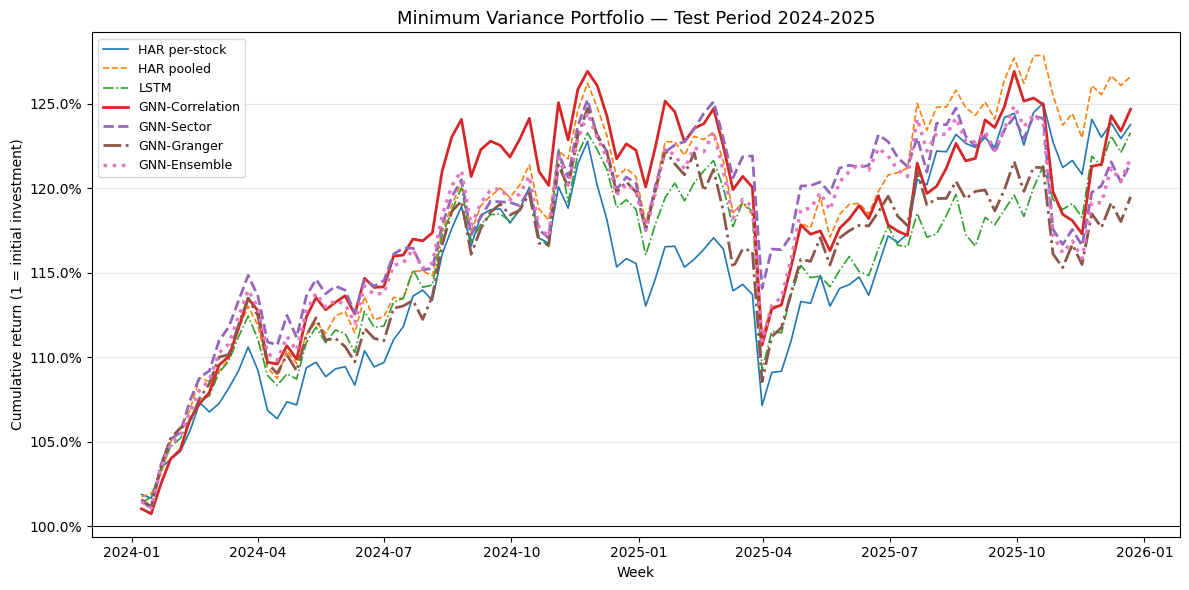

Saved figure: C:\Users\Rylan Wade\Desktop\FinancialAnalytics\Final_Project\data\results\figures\portfolio_mv_cumulative_return.png


In [15]:
fig, ax = plt.subplots(figsize=(12, 6))

mv_model_order = [
    'HAR per-stock', 'HAR pooled', 'LSTM',
    'GNN-Correlation', 'GNN-Sector', 'GNN-Granger', 'GNN-Ensemble',
]
linestyles = ['-',  '--', '-.',  '-',  '--', '-.',  ':' ]
linewidths = [1.2,  1.2,  1.2,   2.0,  2.0,  2.0,   2.5]

for model, ls, lw in zip(mv_model_order, linestyles, linewidths):
    sub = mv_returns_df[mv_returns_df['model'] == model].sort_values('week')
    cum = (1.0 + sub['net_return'].values).cumprod()
    ax.plot(sub['week'].values, cum, label=model, linestyle=ls, linewidth=lw)

ax.axhline(1.0, color='black', linewidth=0.7, linestyle='-')
ax.set_title('Minimum Variance Portfolio — Test Period 2024-2025', fontsize=13)
ax.set_xlabel('Week')
ax.set_ylabel('Cumulative return (1 = initial investment)')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.legend(loc='upper left', fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()

fig_path = pathlib.Path(config.FIGURES_DIR) / 'portfolio_mv_cumulative_return.png'
fig_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(fig_path, dpi=150)
plt.show()
print(f'Saved figure: {fig_path}')

## Frozen baseline portfolio summary

This section reads the frozen Phase 0 baseline snapshot from `data/results/` and displays the model roster plus the saved portfolio metric tables used as the control condition for later portfolio checks.


In [16]:
from src.baseline_freeze import (
    load_frozen_baseline_manifest,
    load_frozen_baseline_roster,
    load_frozen_baseline_table,
)

manifest = load_frozen_baseline_manifest()
roster = load_frozen_baseline_roster()
frozen_ivol = load_frozen_baseline_table("portfolio_metrics_table.csv")
frozen_ls = load_frozen_baseline_table("portfolio_ls_metrics_table.csv")
frozen_vt = load_frozen_baseline_table("portfolio_vt_metrics_table.csv")
frozen_mv = load_frozen_baseline_table("portfolio_mv_metrics_table.csv")

print("Frozen baseline snapshot")
print(f"  created_at_utc: {manifest['created_at_utc']}")
print(f"  manifest path: data/results/frozen_baseline_manifest.json")
print(f"  snapshot dir: data/results/{manifest['snapshot_dir']}")
print(f"  files copied: {manifest['n_files']}")
print(f"  model roster: data/results/{manifest['model_roster_path']}")

display(roster[["model_name", "model_family", "graph_type", "loss_type"]])
display(frozen_ivol)
display(frozen_ls)
display(frozen_vt)
display(frozen_mv)


Frozen baseline snapshot
  created_at_utc: 2026-04-28T21:18:00.323280+00:00
  manifest path: data/results/frozen_baseline_manifest.json
  snapshot dir: data/results/frozen_baseline_20260428T211759Z
  files copied: 233
  model roster: data/results/frozen_baseline_model_roster.csv


,model_name,model_family,graph_type,loss_type
0,HAR per-stock,HAR,none,squared_error
1,HAR pooled,HAR,none,squared_error
2,LSTM,LSTM,none,mse
3,GNN-Correlation,GNN,correlation,mse
4,GNN-Sector,GNN,sector,mse
5,GNN-Granger,GNN,granger,mse
6,GNN-Ensemble,GNN ensemble,correlation+sector+granger,mse
7,Rank-loss GNN-Correlation,GNN,correlation,bpr_rank
8,Rank-loss GNN-Sector,GNN,sector,bpr_rank
9,Rank-loss GNN-Granger,GNN,granger,bpr_rank


,model,ann_return,ann_vol,sharpe,max_drawdown,avg_turnover,max_single_stock_weight
0,HAR per-stock,0.099884,0.126095,0.395608,-0.154781,0.163430,0.007657
1,HAR pooled,0.101814,0.127620,0.406001,-0.158551,0.152096,0.004916
2,LSTM,0.102099,0.126718,0.411143,-0.157998,0.075773,0.005663
3,GNN-Correlation,0.099432,0.127748,0.386947,-0.159239,0.078741,0.004951
4,GNN-Sector,0.102729,0.128707,0.409682,-0.157310,0.071850,0.016102
5,GNN-Granger,0.104603,0.128960,0.423410,-0.160350,0.081782,0.003899
6,GNN-Ensemble,0.103496,0.128338,0.416837,-0.158617,0.058094,0.004021
7,Equal-weight,0.120309,0.137006,0.513179,-0.170673,0.000000,0.002151


,model,ann_return,ann_vol,sharpe,max_drawdown,avg_turnover,max_long_weight
0,GNN-Correlation,-0.264412,0.176776,-1.778586,-0.424828,0.967359,0.008621
1,GNN-Sector,-0.170451,0.175042,-1.259421,-0.368361,0.786073,0.008621
2,GNN-Granger,-0.155005,0.156795,-1.307475,-0.344267,0.982926,0.008621
3,GNN-Ensemble,-0.184553,0.181941,-1.289172,-0.392350,0.719953,0.008621
4,HAR per-stock,-0.168636,0.162051,-1.349181,-0.358651,1.329762,0.008621
5,HAR pooled,-0.191918,0.152842,-1.582800,-0.360419,1.477402,0.008621
6,LSTM,-0.156550,0.165006,-1.251771,-0.354951,0.764814,0.008621


,model,ann_return,ann_vol,sharpe,max_drawdown,avg_turnover,max_single_stock_weight,avg_equity_weight
0,HAR per-stock,0.038381,0.052989,-0.219266,-0.067021,0.076289,0.003181,0.433330
1,HAR pooled,0.038825,0.053796,-0.207720,-0.068621,0.073380,0.002120,0.436449
2,LSTM,0.043681,0.055436,-0.113978,-0.071101,0.033529,0.002442,0.437256
3,GNN-Correlation,0.038549,0.059389,-0.192804,-0.075626,0.052283,0.002361,0.464591
4,GNN-Sector,0.039249,0.048948,-0.219640,-0.061149,0.028083,0.006215,0.381303
5,GNN-Granger,0.039746,0.051324,-0.199788,-0.066144,0.036923,0.001603,0.399605
6,GNN-Ensemble,0.039626,0.052828,-0.196382,-0.067325,0.029461,0.001818,0.412894


,model,ann_return,ann_vol,sharpe,max_drawdown,avg_turnover,max_single_stock_weight
0,HAR per-stock,0.112598,0.098647,0.634571,-0.127314,1.012136,0.05
1,HAR pooled,0.124454,0.102143,0.728926,-0.118945,0.913472,0.05
2,LSTM,0.111802,0.109637,0.563696,-0.114085,0.591400,0.05
3,GNN-Correlation,0.118337,0.117545,0.581368,-0.127615,0.606021,0.05
4,GNN-Sector,0.104297,0.110402,0.491816,-0.089126,0.532922,0.05
5,GNN-Granger,0.096253,0.112301,0.411864,-0.129645,0.675954,0.05
6,GNN-Ensemble,0.105881,0.112234,0.497897,-0.108419,0.491509,0.05


## Macro Feature Portfolio Evaluation

This section reuses the existing portfolio constructors with the registry-selected baseline and macro-feature prediction artifacts.

In [17]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

import config
from src.model_artifacts import (
    load_predictions_from_registry,
    load_step7_prediction_registry,
    paired_macro_deltas,
)
from src.portfolio import (
    run_all_model_backtests,
    run_all_model_long_short_backtests,
    run_all_model_backtests_vol_target,
    run_all_model_backtests_minvar,
)

results_dir = Path(config.DATA_RESULTS_DIR)
figures_dir = Path(config.FIGURES_DIR)
figures_dir.mkdir(parents=True, exist_ok=True)
registry = load_step7_prediction_registry(results_dir)
model_predictions = load_predictions_from_registry(registry, tickers=tickers)
print('Portfolio models from registry:')
display(registry[['experiment_id', 'model_name', 'feature_version', 'prediction_path']])

Portfolio models from registry:


,experiment_id,model_name,feature_version,prediction_path
0,baseline_har_per_stock,HAR per-stock,har_realized_volatility_lags_v1,data/results/test_preds_har.parquet
1,baseline_har_pooled,HAR pooled,har_realized_volatility_lags_v1,data/results/test_preds_har_pooled.parquet
2,baseline_lstm,LSTM,stock_features_v1,data/results/test_preds_lstm.parquet
3,macro_lstm,LSTM + Macro,stock_features_plus_regime_v1,data/results/test_preds_lstm_macro.parquet
4,baseline_gnn_correlation,GNN-Correlation,stock_features_v1,data/results/test_preds_gnn_corr.parquet
5,macro_gnn_correlation,GNN-Correlation + Macro,stock_features_plus_regime_v1,data/results/test_preds_gnn_corr_macro.parquet
6,macro_gnn_correlation_hparam,GNN-Correlation + Macro Tuned,stock_features_plus_regime_v1,data/results/test_preds_gnn_corr_macro_hparam....
7,window_gnn_correlation_macro_21_hparam,GNN-Correlation + Macro 21d Tuned,stock_features_plus_regime_v1,data/results/test_preds_gnn_corr_macro_w021_hp...
8,window_gnn_correlation_macro_63_hparam,GNN-Correlation + Macro 63d Tuned,stock_features_plus_regime_v1,data/results/test_preds_gnn_corr_macro_w063_hp...
9,window_gnn_correlation_macro_126_hparam,GNN-Correlation + Macro 126d Tuned,stock_features_plus_regime_v1,data/results/test_preds_gnn_corr_macro_w126_hp...


In [18]:
portfolio_returns_df, metrics_table = run_all_model_backtests(
    log_returns_df=log_returns,
    tbill_rates=tbill_rates,
    tickers=tickers,
    model_predictions=model_predictions,
)
ls_returns_df, ls_metrics_table = run_all_model_long_short_backtests(
    log_returns_df=log_returns,
    tbill_rates=tbill_rates,
    tickers=tickers,
    model_predictions=model_predictions,
)
vt_returns_df, vt_metrics_table = run_all_model_backtests_vol_target(
    log_returns_df=log_returns,
    tbill_rates=tbill_rates,
    tickers=tickers,
    model_predictions=model_predictions,
)
mv_returns_df, mv_metrics_table = run_all_model_backtests_minvar(
    log_returns_df=log_returns,
    tbill_rates=tbill_rates,
    tickers=tickers,
    model_predictions=model_predictions,
)

portfolio_delta_tables = []
for strategy, table in {
    'inverse_vol': metrics_table,
    'long_short': ls_metrics_table,
    'volatility_targeted': vt_metrics_table,
    'minimum_variance': mv_metrics_table,
}.items():
    deltas = paired_macro_deltas(table, ['ann_return', 'ann_vol', 'sharpe', 'max_drawdown', 'avg_turnover'])
    deltas.insert(0, 'strategy', strategy)
    portfolio_delta_tables.append(deltas)
portfolio_deltas = pd.concat(portfolio_delta_tables, ignore_index=True)
portfolio_deltas.to_csv(results_dir / 'macro_portfolio_metric_deltas.csv', index=False)
print('Saved macro-inclusive portfolio tables and macro_portfolio_metric_deltas.csv')

MINIMUM VARIANCE BACKTEST
  MAX_WEIGHT        = 5%
  CORR_LOOKBACK_DAYS= 252
  Models            = ['HAR per-stock', 'HAR pooled', 'LSTM', 'LSTM + Macro', 'GNN-Correlation', 'GNN-Correlation + Macro', 'GNN-Correlation + Macro Tuned', 'GNN-Correlation + Macro 21d Tuned', 'GNN-Correlation + Macro 63d Tuned', 'GNN-Correlation + Macro 126d Tuned', 'GNN-Sector', 'GNN-Sector + Macro', 'GNN-Granger', 'GNN-Granger + Macro', 'GNN-Ensemble', 'GNN-Ensemble + Macro']

Using provided prediction frames...
  HAR per-stock         shape=(103, 465)  NaN=0.000%  pred_range=[0.0643, 3.1389]
  HAR pooled            shape=(103, 465)  NaN=0.000%  pred_range=[0.1001, 2.2918]
  LSTM                  shape=(103, 465)  NaN=0.000%  pred_range=[0.0858, 1.9006]
  LSTM + Macro          shape=(103, 465)  NaN=0.000%  pred_range=[0.1421, 1.7055]
  GNN-Correlation       shape=(103, 465)  NaN=0.000%  pred_range=[0.0929, 0.8642]
  GNN-Correlation + Macro  shape=(103, 465)  NaN=0.000%  pred_range=[0.1775, 0.5387]
  GNN-Co

  [ 60/103]  week=2025-02-17  window_rows=252  C_shape=(465, 465)  NaN_zeroed=0  density(|r|>0.3)=0.179  time=3.8ms
  [ 80/103]  week=2025-07-07  window_rows=252  C_shape=(465, 465)  NaN_zeroed=0  density(|r|>0.3)=0.514  time=3.8ms
  [100/103]  week=2025-11-24  window_rows=252  C_shape=(465, 465)  NaN_zeroed=928  density(|r|>0.3)=0.493  time=3.6ms
  [103/103]  week=2025-12-15  window_rows=252  C_shape=(465, 465)  NaN_zeroed=928  density(|r|>0.3)=0.493  time=3.8ms

  Correlation phase complete: 103 matrices in 0.40s  (3.8ms/matrix)
  Total NaN cells zeroed: 5568  (max in any week: 928)

------------------------------------------------------------------------
PHASE 2 — Per-model QP solves  (solver: OSQP)
------------------------------------------------------------------------
  Constraint matrix A: shape=(466, 465)  nnz=930  (precomputed once, reused every solve)


  Model 1/16: HAR per-stock


    [  1/103]  week=2024-01-01  solve=133.6ms  active_stocks=43  max_w=0.0500  net_ret=+0.0188  turnover=0.0000  ETA=14s


    [ 20/103]  week=2024-05-13  solve=100.5ms  active_stocks=45  max_w=0.0500  net_ret=-0.0078  turnover=0.9280  ETA=10s


    [ 40/103]  week=2024-09-30  solve=85.8ms  active_stocks=52  max_w=0.0500  net_ret=+0.0066  turnover=1.0508  ETA=7s


...

    [ 40/103]  week=2024-09-30  solve=84.6ms  active_stocks=57  max_w=0.0500  net_ret=+0.0059  turnover=0.3052  ETA=5s


    [ 60/103]  week=2025-02-17  solve=89.9ms  active_stocks=60  max_w=0.0500  net_ret=+0.0053  turnover=0.4641  ETA=4s


    [ 80/103]  week=2025-07-07  solve=162.6ms  active_stocks=41  max_w=0.0500  net_ret=-0.0004  turnover=0.2996  ETA=2s


    [100/103]  week=2025-11-24  solve=76.3ms  active_stocks=44  max_w=0.0500  net_ret=-0.0021  turnover=0.2439  ETA=0s


    [103/103]  week=2025-12-15  solve=70.9ms  active_stocks=47  max_w=0.0500  net_ret=+0.0123  turnover=0.2745  ETA=0s

    --- GNN-Ensemble + Macro complete in 9.3s ---
    solve times:   mean=89.7ms  max=207.0ms  min=65.8ms
    active stocks: mean=51.6  min=39  max=68
    ann_return=14.94%  ann_vol=10.87%  sharpe=0.914  max_drawdown=-9.88%
    avg_turnover=0.3575  max_weight=0.0500

------------------------------------------------------------------------
ASSEMBLING RESULTS
------------------------------------------------------------------------

SUMMARY
  Correlation phase : 0.40s
  QP solve phase    : 173.47s
  Total             : 173.86s

                                    ann_return   ann_vol    sharpe  max_drawdown  avg_turnover  max_single_stock_weight
model                                                                                                                  
HAR per-stock                         0.112598  0.098647  0.634571     -0.127314      1.012136               

In [19]:
print('Inverse-volatility portfolio metrics')
display(metrics_table.style.format(precision=4))
print('Long-short portfolio metrics')
display(ls_metrics_table.style.format(precision=4))
print('Volatility-targeted portfolio metrics')
display(vt_metrics_table.style.format(precision=4))
print('Minimum-variance portfolio metrics')
display(mv_metrics_table.style.format(precision=4))
print('Macro minus matched-baseline portfolio deltas')
display(portfolio_deltas.style.format(precision=6))

Inverse-volatility portfolio metrics


,ann_return,ann_vol,sharpe,max_drawdown,avg_turnover,max_single_stock_weight
model,,,,,,
HAR per-stock,0.0999,0.1261,0.3956,-0.1548,0.1634,0.0077
HAR pooled,0.1018,0.1276,0.4060,-0.1586,0.1521,0.0049
LSTM,0.1021,0.1267,0.4111,-0.1580,0.0758,0.0057
LSTM + Macro,0.1031,0.1278,0.4156,-0.1602,0.0491,0.0044
GNN-Correlation,0.0994,0.1277,0.3869,-0.1592,0.0787,0.0050
GNN-Correlation + Macro,0.1097,0.1300,0.4591,-0.1603,0.0386,0.0034
GNN-Correlation + Macro Tuned,0.1031,0.1249,0.4251,-0.1510,0.0902,0.0081
GNN-Correlation + Macro 21d Tuned,0.1077,0.1279,0.4511,-0.1562,0.0913,0.0050
GNN-Correlation + Macro 63d Tuned,0.1041,0.1260,0.4292,-0.1538,0.0781,0.0068


Long-short portfolio metrics


,ann_return,ann_vol,sharpe,max_drawdown,avg_turnover,max_long_weight
model,,,,,,
HAR per-stock,-0.1686,0.1621,-1.3492,-0.3587,1.3298,0.0086
HAR pooled,-0.1919,0.1528,-1.5828,-0.3604,1.4774,0.0086
LSTM,-0.1565,0.1650,-1.2518,-0.3550,0.7648,0.0086
LSTM + Macro,-0.1591,0.1719,-1.2161,-0.3788,0.5787,0.0086
GNN-Correlation,-0.2644,0.1768,-1.7786,-0.4248,0.9674,0.0086
GNN-Correlation + Macro,-0.1479,0.1764,-1.1219,-0.3772,0.5884,0.0086
GNN-Correlation + Macro Tuned,-0.1794,0.1909,-1.2016,-0.3703,0.8420,0.0086
GNN-Correlation + Macro 21d Tuned,-0.1611,0.1706,-1.2373,-0.3530,1.0896,0.0086
GNN-Correlation + Macro 63d Tuned,-0.1743,0.1861,-1.2057,-0.3725,0.9029,0.0086


Volatility-targeted portfolio metrics


,ann_return,ann_vol,sharpe,max_drawdown,avg_turnover,max_single_stock_weight,avg_equity_weight
model,,,,,,,
HAR per-stock,0.0384,0.0530,-0.2193,-0.0670,0.0763,0.0032,0.4333
HAR pooled,0.0388,0.0538,-0.2077,-0.0686,0.0734,0.0021,0.4364
LSTM,0.0437,0.0554,-0.1140,-0.0711,0.0335,0.0024,0.4373
LSTM + Macro,0.0311,0.0453,-0.4172,-0.0564,0.0336,0.0016,0.3752
GNN-Correlation,0.0385,0.0594,-0.1928,-0.0756,0.0523,0.0024,0.4646
GNN-Correlation + Macro,0.0439,0.0576,-0.1063,-0.0733,0.0307,0.0013,0.4659
GNN-Correlation + Macro Tuned,0.0300,0.0556,-0.3586,-0.0682,0.0661,0.0023,0.4494
GNN-Correlation + Macro 21d Tuned,0.0449,0.0600,-0.0855,-0.0733,0.0604,0.0022,0.4859
GNN-Correlation + Macro 63d Tuned,0.0404,0.0561,-0.1717,-0.0667,0.0531,0.0035,0.4675


Minimum-variance portfolio metrics


,ann_return,ann_vol,sharpe,max_drawdown,avg_turnover,max_single_stock_weight
model,,,,,,
HAR per-stock,0.1126,0.0986,0.6346,-0.1273,1.0121,0.0500
HAR pooled,0.1245,0.1021,0.7289,-0.1189,0.9135,0.0500
LSTM,0.1118,0.1096,0.5637,-0.1141,0.5914,0.0500
LSTM + Macro,0.1243,0.1058,0.7021,-0.1136,0.4231,0.0500
GNN-Correlation,0.1183,0.1175,0.5814,-0.1276,0.6060,0.0500
GNN-Correlation + Macro,0.1283,0.1143,0.6849,-0.1102,0.3709,0.0500
GNN-Correlation + Macro Tuned,0.1175,0.1005,0.6711,-0.0856,0.7700,0.0500
GNN-Correlation + Macro 21d Tuned,0.1372,0.1052,0.8284,-0.1031,0.7204,0.0500
GNN-Correlation + Macro 63d Tuned,0.1334,0.1049,0.7945,-0.0922,0.6704,0.0500


Macro minus matched-baseline portfolio deltas


,strategy,baseline_model,macro_model,baseline_ann_return,macro_ann_return,delta_ann_return,baseline_ann_vol,macro_ann_vol,delta_ann_vol,baseline_sharpe,macro_sharpe,delta_sharpe,baseline_max_drawdown,macro_max_drawdown,delta_max_drawdown,baseline_avg_turnover,macro_avg_turnover,delta_avg_turnover
0,inverse_vol,LSTM,LSTM + Macro,0.102099,0.103111,0.001012,0.126718,0.127791,0.001073,0.411143,0.415609,0.004467,-0.157998,-0.160173,-0.002175,0.075773,0.049071,-0.026702
1,inverse_vol,GNN-Correlation,GNN-Correlation + Macro,0.099432,0.109668,0.010237,0.127748,0.129965,0.002217,0.386947,0.459113,0.072165,-0.159239,-0.160333,-0.001094,0.078741,0.038610,-0.040131
2,inverse_vol,GNN-Correlation,GNN-Correlation + Macro Tuned,0.099432,0.103083,0.003651,0.127748,0.124872,-0.002875,0.386947,0.425094,0.038147,-0.159239,-0.150951,0.008288,0.078741,0.090204,0.011463
3,inverse_vol,GNN-Correlation,GNN-Correlation + Macro 21d Tuned,0.099432,0.107716,0.008284,0.127748,0.127945,0.000198,0.386947,0.451099,0.064151,-0.159239,-0.156197,0.003041,0.078741,0.091293,0.012552
4,inverse_vol,GNN-Correlation,GNN-Correlation + Macro 63d Tuned,0.099432,0.104067,0.004635,0.127748,0.125982,-0.001766,0.386947,0.429164,0.042217,-0.159239,-0.153821,0.005417,0.078741,0.078100,-0.000641
5,inverse_vol,GNN-Correlation,GNN-Correlation + Macro 126d Tuned,0.099432,0.102192,0.002760,0.127748,0.125710,-0.002037,0.386947,0.415177,0.028229,-0.159239,-0.154305,0.004934,0.078741,0.113454,0.034713
6,inverse_vol,GNN-Sector,GNN-Sector + Macro,0.102729,0.110341,0.007612,0.128707,0.128913,0.000206,0.409682,0.468077,0.058395,-0.157310,-0.159423,-0.002113,0.071850,0.050360,-0.021490
7,inverse_vol,GNN-Granger,GNN-Granger + Macro,0.104603,0.109673,0.005071,0.128960,0.130834,0.001874,0.423410,0.456100,0.032691,-0.160350,-0.163888,-0.003537,0.081782,0.052625,-0.029157
8,inverse_vol,GNN-Ensemble,GNN-Ensemble + Macro,0.103489,0.110346,0.006857,0.128337,0.129855,0.001518,0.416790,0.464722,0.047932,-0.158617,-0.160978,-0.002361,0.058086,0.037182,-0.020903
9,long_short,LSTM,LSTM + Macro,-0.156550,-0.159072,-0.002523,0.165006,0.171926,0.006920,-1.251771,-1.216058,0.035713,-0.354951,-0.378841,-0.023890,0.764814,0.578674,-0.186140


Saved figure: C:\Users\Rylan Wade\Desktop\FinancialAnalytics\Final_Project\data\results\figures\macro_portfolio_cumulative_return.png


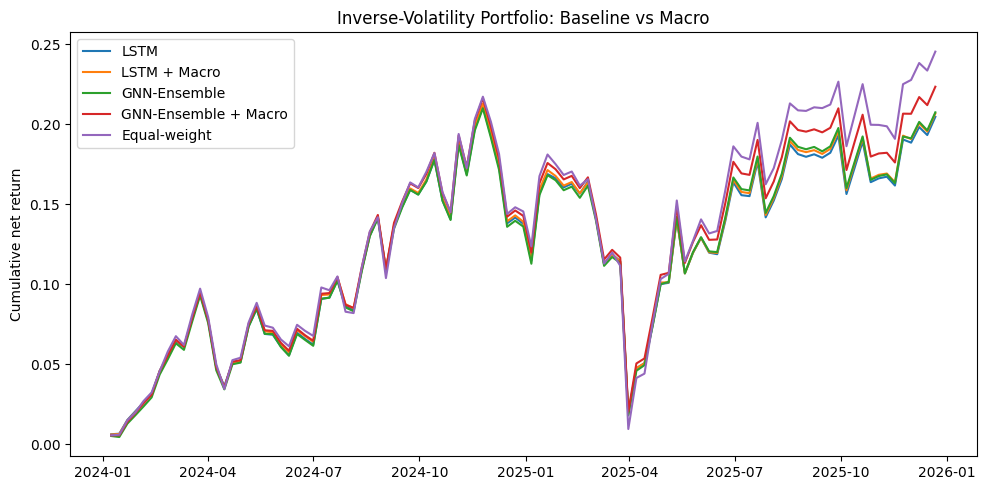

In [20]:
plot_models = ['LSTM', 'LSTM + Macro', 'GNN-Ensemble', 'GNN-Ensemble + Macro', 'Equal-weight']
available = [m for m in plot_models if m in set(portfolio_returns_df['model'])]
fig, ax = plt.subplots(figsize=(10, 5))
for model in available:
    sub = portfolio_returns_df.loc[portfolio_returns_df['model'] == model].sort_values('week')
    cumulative = (1.0 + sub['net_return']).cumprod() - 1.0
    ax.plot(sub['week'], cumulative, label=model)
ax.set_title('Inverse-Volatility Portfolio: Baseline vs Macro')
ax.set_ylabel('Cumulative net return')
ax.legend()
fig.tight_layout()
fig_path = figures_dir / 'macro_portfolio_cumulative_return.png'
fig.savefig(fig_path, dpi=150, bbox_inches='tight')
print(f'Saved figure: {fig_path}')
plt.show()